In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import copy
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS

In [2]:
df = pd.read_csv("../../data/indoorAir2.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s') 
df = df.sort_values(by='timestamp')

print(df.shape)
df.head()

(1924653, 21)


,id,station_id,station_name,timestamp,scd41_co2,scd41_temperature,scd41_humidity,ens160_eco2,ens160_tvoc,ens160_aqi,...,svm41_humidity,svm41_nox_index,svm41_voc_index,bme688_temperature,bme688_humidity,bme688_pressure,bme688_gas_resistance,sfa30_temperature,sfa30_humidity,sfa30_hco
0,1,1,station_room_233,2024-11-13 16:57:56,488.0,22.951857,36.897277,418,32,1,...,34.060001,29.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,station_room_233,2024-11-13 16:58:57,485.0,22.335011,38.185119,414,30,1,...,34.209999,79.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,station_room_233,2024-11-13 16:59:59,477.0,22.353704,38.400268,443,43,1,...,34.180000,99.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,station_room_233,2024-11-13 17:01:03,474.0,22.417792,38.269042,406,26,1,...,34.130001,93.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,station_room_233,2024-11-13 17:02:05,473.0,22.556649,37.971496,416,31,1,...,34.240001,98.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# # Hour cyclic features
# df["hour"] = df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60

# df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
# df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# # Day of week cyclic features
# df["dayofweek"] = df["timestamp"].dt.dayofweek

# df["dayofweek_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
# df["dayofweek_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

# # Weekend feature
# df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

# feature_df = df[
#     [
#         "ens160_aqi",
#         "ens160_tvoc",
#         "bme688_gas_resistance",
#         "bme688_pressure",
#         "scd41_temperature",
#         "scd41_humidity",
#         "timestamp",
#         "scd41_co2",
#         "hour_sin",
#         "hour_cos",
#         "dayofweek_sin",
#         "dayofweek_cos",
#         "is_weekend",
#         "station_id",
#     ]
# ].copy()

df = df[df["station_id"] != 6].copy()

feature_df = df[
    [
        "ens160_aqi",
        "ens160_tvoc",
        "bme688_gas_resistance",
        "bme688_pressure",
        "scd41_temperature",
        "scd41_humidity",
        "timestamp",
        "scd41_co2",
        "station_id",
    ]
].copy()
print(feature_df.shape)
feature_df.head()

(1924649, 9)


,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,timestamp,scd41_co2,station_id
0,1,32,NaN,NaN,22.951857,36.897277,2024-11-13 16:57:56,488.0,1
1,1,30,NaN,NaN,22.335011,38.185119,2024-11-13 16:58:57,485.0,1
2,1,43,NaN,NaN,22.353704,38.400268,2024-11-13 16:59:59,477.0,1
3,1,26,NaN,NaN,22.417792,38.269042,2024-11-13 17:01:03,474.0,1
4,1,31,NaN,NaN,22.556649,37.971496,2024-11-13 17:02:05,473.0,1


In [4]:
resample_freq = "15min"   # or "5min", etc.

value_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
]

feature_df = (
    feature_df
    .sort_values(["station_id", "timestamp"])
    .set_index("timestamp")
    .groupby("station_id")[value_cols]
    .resample(resample_freq)
    .mean()
    .reset_index()
)

feature_df[value_cols] = (
    feature_df
    .groupby("station_id")[value_cols]
    .transform(lambda x: x.interpolate(method="linear").ffill().bfill())
)

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

print(feature_df.shape)
feature_df.head()

(186889, 9)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408


In [5]:
print(feature_df.shape)
# Sort before merge_asof
feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

# Create target lookup dataframe
target_df = feature_df[["station_id", "timestamp", "scd41_co2"]].copy()

target_df = target_df.rename(
    columns={
        "timestamp": "actual_target_timestamp",
        "scd41_co2": "target_co2_15min"
    }
)

# Required future timestamp
feature_df["target_timestamp"] = feature_df["timestamp"] + pd.Timedelta(minutes=15)

# Sort for merge_asof
feature_df = feature_df.sort_values(["target_timestamp", "station_id"]).reset_index(drop=True)
target_df = target_df.sort_values(["actual_target_timestamp", "station_id"]).reset_index(drop=True)

# Find nearest CO2 value around timestamp + 15 min
feature_df = pd.merge_asof(
    feature_df,
    target_df,
    left_on="target_timestamp",
    right_on="actual_target_timestamp",
    by="station_id",
    direction="nearest",
    tolerance=pd.Timedelta(minutes=2)
)

# Check actual difference from exact 15 min
feature_df["target_diff_seconds"] = (
    feature_df["actual_target_timestamp"] - feature_df["target_timestamp"]
).abs().dt.total_seconds()

# Remove rows without valid 15-min target
feature_df = feature_df.dropna(subset=["target_co2_15min"]).reset_index(drop=True)

feature_df = feature_df.drop(
    columns=[
        "target_timestamp",
        "actual_target_timestamp",
        "target_diff_seconds"
    ]
)

print(feature_df.shape)
feature_df.head()

(186889, 9)
(186884, 10)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,target_co2_15min
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,472.285714
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,471.997279
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,471.708844
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,471.420408
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,471.131973


In [6]:
cols_to_fill = ["bme688_gas_resistance", "bme688_pressure"]

#feature_df = feature_df.sort_values("station_id").reset_index(drop=True)
feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

feature_df[cols_to_fill] = (
    feature_df
    .groupby("station_id")[cols_to_fill]
    .transform(lambda x: x.interpolate(method="linear"))
)

feature_df[cols_to_fill] = (
    feature_df
    .groupby("station_id")[cols_to_fill]
    .ffill()
    .bfill()
)

print(feature_df.shape)
feature_df.head()

(186884, 10)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,target_co2_15min
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,472.285714
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,471.997279
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,471.708844
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,471.420408
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,471.131973


In [7]:
numeric_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
    "target_co2_15min"
]

for col in numeric_cols:
    Q1 = feature_df[col].quantile(0.25)
    Q3 = feature_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    feature_df[col] = feature_df[col].clip(lower=lower, upper=upper)

print(feature_df.shape)
feature_df.head()

(186884, 10)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,target_co2_15min
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,472.285714
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,471.997279
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,471.708844
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,471.420408
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,471.131973


In [8]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = feature_df[col].quantile(0.25)
    Q3 = feature_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((feature_df[col] < lower) | (feature_df[col] > upper)).sum()

    outlier_summary[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_percent": (outlier_count / len(feature_df)) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

                        lower_bound   upper_bound  outlier_count  \
ens160_aqi            -5.000000e-01  3.500000e+00            0.0   
ens160_tvoc           -9.768571e+01  2.889048e+02            0.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07            0.0   
bme688_pressure        9.849031e+01  1.018882e+02            0.0   
scd41_temperature      1.971432e+01  2.910343e+01            0.0   
scd41_humidity         8.847241e+00  6.352849e+01            0.0   
scd41_co2              2.501637e+02  7.448383e+02            0.0   
target_co2_15min       2.501637e+02  7.448383e+02            0.0   

                       outlier_percent  
ens160_aqi                         0.0  
ens160_tvoc                        0.0  
bme688_gas_resistance              0.0  
bme688_pressure                    0.0  
scd41_temperature                  0.0  
scd41_humidity                     0.0  
scd41_co2                          0.0  
target_co2_15min                   0.0  


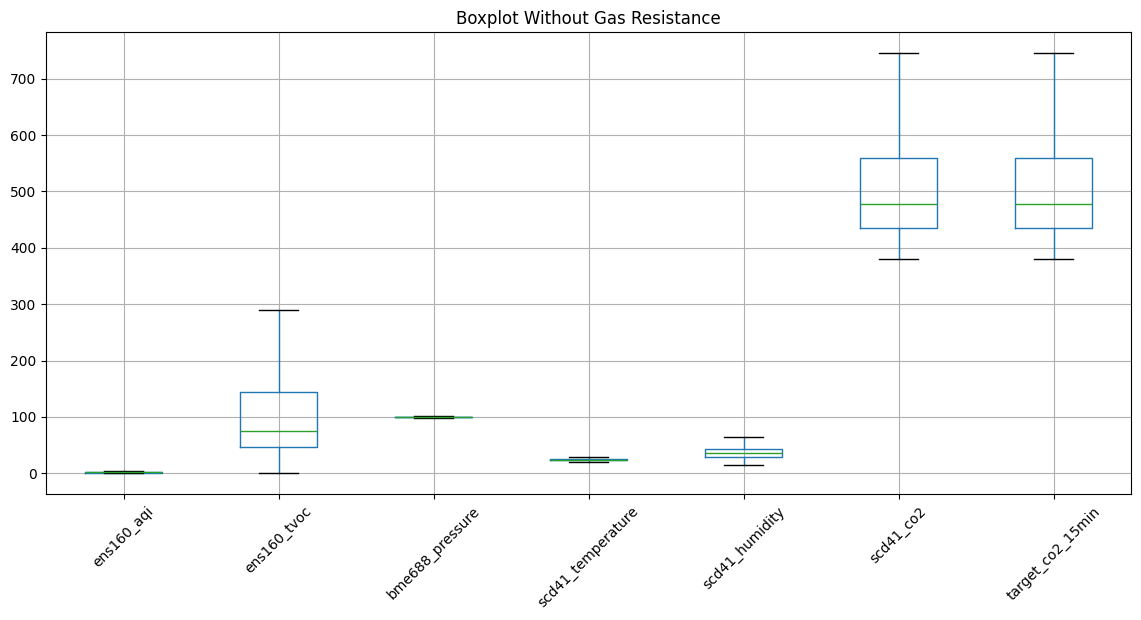

In [9]:
plot_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
    "target_co2_15min"
]

feature_df[plot_cols].boxplot(figsize=(14, 6), rot=45)
plt.title("Boxplot Without Gas Resistance")
plt.show()

In [10]:
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

def split_station_data(station_data):
    station_data = station_data.sort_values("timestamp")
    n_rows = len(station_data)
    train_end = int(n_rows * train_ratio)
    val_end = train_end + int(n_rows * val_ratio)

    return (
        station_data.iloc[:train_end],
        station_data.iloc[train_end:val_end],
        station_data.iloc[val_end:],
    )

train_parts = []
val_parts = []
test_parts = []

for station_id, station_data in feature_df.groupby("station_id", sort=True):
    station_train, station_val, station_test = split_station_data(station_data)
    train_parts.append(station_train)
    val_parts.append(station_val)
    test_parts.append(station_test)

train_df = pd.concat(train_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)
val_df = pd.concat(val_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)
test_df = pd.concat(test_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)

total_rows = len(feature_df)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("Train percentage:", len(train_df) / total_rows * 100)
print("Val percentage:", len(val_df) / total_rows * 100)
print("Test percentage:", len(test_df) / total_rows * 100)

split_counts = pd.concat(
    [
        train_df.groupby("station_id").size().rename("train"),
        val_df.groupby("station_id").size().rename("val"),
        test_df.groupby("station_id").size().rename("test"),
    ],
    axis=1,
).fillna(0).astype(int)

print("\nRows per station:")
print(split_counts)

Train shape: (130816, 10)
Val shape: (28031, 10)
Test shape: (28037, 10)
Train percentage: 69.99850174439759
Val percentage: 14.999143853941483
Test percentage: 15.002354401660922

Rows per station:
            train   val  test
station_id                   
1           35269  7557  7559
2           13566  2907  2908
3           30913  6624  6625
4           30627  6563  6564
5           20441  4380  4381


In [11]:
target_col = "target_co2_15min"

"""feature_cols = [
    col for col in feature_df.columns
    if col != target_col
]"""
feature_cols = [
    col for col in feature_df.columns
    if col not in [target_col, "timestamp"]
]

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[feature_cols] = x_scaler.fit_transform(train_df[feature_cols])
val_df_scaled[feature_cols] = x_scaler.transform(val_df[feature_cols])
test_df_scaled[feature_cols] = x_scaler.transform(test_df[feature_cols])

train_df_scaled[[target_col]] = y_scaler.fit_transform(train_df[[target_col]])
val_df_scaled[[target_col]] = y_scaler.transform(val_df[[target_col]])
test_df_scaled[[target_col]] = y_scaler.transform(test_df[[target_col]])

print("Scaled X min/max:", train_df_scaled[feature_cols].min().min(), train_df_scaled[feature_cols].max().max())
print("Scaled y min/max:", train_df_scaled[target_col].min(), train_df_scaled[target_col].max())

Scaled X min/max: 0.0 1.0000000000000002
Scaled y min/max: 0.0 1.0000000000000002


In [12]:
# Historical Data 5 days - prediction 2 hour
history_days = 5
prediction_hours = 2

steps_per_hour = int(pd.Timedelta(hours=1) / pd.Timedelta(resample_freq))

input_size = history_days * 24 * steps_per_hour
horizon = prediction_hours * steps_per_hour

# Better SyN-BEATS tuning
learning_rate = 0.0001
dropout = 0.25
hidden_dim = 64
num_blocks = 2
num_layers = 2
batch_size = 128
num_epochs = 50

print("Input size:", input_size)
print("Horizon:", horizon)

Input size: 480
Horizon: 8


In [13]:
def create_windows(data, feature_cols, target_col="target_co2_15min"):
    X_windows = []
    y_windows = []

    data = data.sort_values(["station_id", "timestamp"])

    for station_id, station_data in data.groupby("station_id"):
        X = station_data[feature_cols].values.astype("float32")
        y = station_data[target_col].values.astype("float32")

        for i in range(input_size, len(station_data) - horizon + 2):
            X_windows.append(X[i - input_size:i])
            y_windows.append(y[i - 1:i - 1 + horizon])

    return np.array(X_windows, dtype="float32"), np.array(y_windows, dtype="float32")


X_train, y_train = create_windows(train_df_scaled, feature_cols, target_col)
X_val, y_val = create_windows(val_df_scaled, feature_cols, target_col)
X_test, y_test = create_windows(test_df_scaled, feature_cols, target_col)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (128386, 480, 8) y_train: (128386, 8)
X_val: (25601, 480, 8) y_val: (25601, 8)
X_test: (25607, 480, 8) y_test: (25607, 8)


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))
print("Device:", device)

Train batches: 1004
Val batches: 201
Test batches: 201
Device: cpu


In [15]:
class NBeatsBlock(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        theta_dim,
        num_layers=2,
        dropout=0.25,
        use_layer_norm=False,
        activation_cls=nn.ReLU
    ):
        super(NBeatsBlock, self).__init__()

        layers = []

        for layer_idx in range(num_layers):
            in_dim = input_dim if layer_idx == 0 else hidden_dim

            layers.append(nn.Linear(in_dim, hidden_dim))

            if use_layer_norm:
                layers.append(nn.LayerNorm(hidden_dim))

            layers.append(activation_cls())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

        self.fc = nn.Sequential(*layers)
        self.backcast_layer = nn.Linear(hidden_dim, input_dim)
        self.forecast_layer = nn.Linear(hidden_dim, theta_dim)

    def forward(self, x):
        h = self.fc(x)
        backcast = self.backcast_layer(h)
        forecast = self.forecast_layer(h)
        return backcast, forecast

In [16]:
class NBeats(nn.Module):
    def __init__(
        self,
        input_size,
        num_features,
        hidden_dim=64,
        num_blocks=2,
        num_layers=2,
        horizon=8,
        dropout=0.25,
        block_cls=NBeatsBlock,
        block_kwargs=None
    ):
        super(NBeats, self).__init__()

        self.input_dim = input_size * num_features
        self.horizon = horizon
        block_kwargs = block_kwargs or {}

        self.blocks = nn.ModuleList([
            block_cls(
                input_dim=self.input_dim,
                hidden_dim=hidden_dim,
                theta_dim=horizon,
                num_layers=num_layers,
                dropout=dropout,
                **block_kwargs
            )
            for _ in range(num_blocks)
        ])

    def forward(self, x):
        x = x.reshape(x.size(0), -1)

        residual = x
        forecast = torch.zeros(x.size(0), self.horizon, device=x.device)

        for block in self.blocks:
            backcast, block_forecast = block(residual)
            residual = residual - backcast
            forecast = forecast + block_forecast

        return forecast


class SyNBeats(NBeats):
    def __init__(self, *args, **kwargs):
        kwargs["block_kwargs"] = {
            "use_layer_norm": True,
            "activation_cls": nn.SiLU
        }

        super(SyNBeats, self).__init__(*args, **kwargs)

        # Conservative gate initialization.
        # sigmoid(-1.0) is about 0.27, so residual updates are less aggressive.
        self.residual_gates = nn.Parameter(torch.full((len(self.blocks),), -1.0))

    def forward(self, x):
        x = x.reshape(x.size(0), -1)

        residual = x
        forecast = torch.zeros(x.size(0), self.horizon, device=x.device)

        for block_idx, block in enumerate(self.blocks):
            backcast, block_forecast = block(residual)

            gate = torch.sigmoid(self.residual_gates[block_idx])
            residual = residual - gate * backcast
            forecast = forecast + block_forecast

        return forecast

In [17]:
# num_features = X_train.shape[2]
# criterion = nn.MSELoss()


# def build_model(model_class):
#     model = model_class(
#         input_size=input_size,
#         num_features=num_features,
#         hidden_dim=hidden_dim,
#         num_blocks=num_blocks,
#         num_layers=num_layers,
#         horizon=horizon,
#         dropout=dropout
#     )

#     return model.to(device)


# def train_model(model_name, model):
#     optimizer = optim.Adam(
#         model.parameters(),
#         lr=learning_rate,
#         weight_decay=1e-4
#     )

#     scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#         optimizer,
#         mode="min",
#         factor=0.5,
#         patience=3
#     )

#     train_losses = []
#     val_losses = []

#     best_val_loss = float("inf")
#     best_model_state = None

#     patience = 7
#     patience_counter = 0

#     for epoch in range(num_epochs):
#         model.train()
#         running_train_loss = 0.0

#         for X_batch, y_batch in train_loader:
#             X_batch = X_batch.to(device)
#             y_batch = y_batch.to(device)

#             optimizer.zero_grad()

#             y_pred = model(X_batch)
#             loss = criterion(y_pred, y_batch)

#             loss.backward()

#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#             optimizer.step()

#             running_train_loss += loss.item()

#         avg_train_loss = running_train_loss / len(train_loader)

#         model.eval()
#         running_val_loss = 0.0

#         with torch.no_grad():
#             for X_batch, y_batch in val_loader:
#                 X_batch = X_batch.to(device)
#                 y_batch = y_batch.to(device)

#                 y_pred = model(X_batch)
#                 loss = criterion(y_pred, y_batch)

#                 running_val_loss += loss.item()

#         avg_val_loss = running_val_loss / len(val_loader)

#         scheduler.step(avg_val_loss)

#         train_losses.append(avg_train_loss)
#         val_losses.append(avg_val_loss)

#         print(
#             f"{model_name} Epoch [{epoch + 1}/{num_epochs}] "
#             f"Train Loss: {avg_train_loss:.6f} "
#             f"Val Loss: {avg_val_loss:.6f}"
#         )

#         if avg_val_loss < best_val_loss:
#             best_val_loss = avg_val_loss
#             best_model_state = copy.deepcopy(model.state_dict())
#             patience_counter = 0
#         else:
#             patience_counter += 1

#         if patience_counter >= patience:
#             print(f"{model_name} Early stopping at epoch {epoch + 1}")
#             break

#     model.load_state_dict(best_model_state)

#     print(f"{model_name} Best Val Loss:", best_val_loss)

#     return {
#         "model": model,
#         "train_losses": train_losses,
#         "val_losses": val_losses,
#         "best_val_loss": best_val_loss
#     # }




num_features = X_train.shape[2]
criterion = nn.MSELoss()


def build_model(model_class):
    model = model_class(
        input_size=input_size,
        num_features=num_features,
        hidden_dim=hidden_dim,
        num_blocks=num_blocks,
        num_layers=num_layers,
        horizon=horizon,
        dropout=dropout
    )

    return model.to(device)


def train_model(model_name, model):
    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)

        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)

                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)

        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(
            f"{model_name} Epoch [{epoch + 1}/{num_epochs}] "
            f"Train Loss: {avg_train_loss:.6f} "
            f"Val Loss: {avg_val_loss:.6f}"
        )

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_state)

    print(f"{model_name} Best Val Loss:", best_val_loss)

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss
    }

In [18]:
experiment_results = {}

models_to_compare = {
    "N-BEATS": NBeats,
    "SyN-BEATS": SyNBeats
}

for model_name, model_class in models_to_compare.items():
    print("\nTraining:", model_name)

    model = build_model(model_class)
    experiment_results[model_name] = train_model(model_name, model)


Training: N-BEATS
N-BEATS Epoch [1/50] Train Loss: 0.025413 Val Loss: 0.014109
N-BEATS Epoch [2/50] Train Loss: 0.012738 Val Loss: 0.012557
N-BEATS Epoch [3/50] Train Loss: 0.010800 Val Loss: 0.010546
N-BEATS Epoch [4/50] Train Loss: 0.009885 Val Loss: 0.008697
N-BEATS Epoch [5/50] Train Loss: 0.009205 Val Loss: 0.008949
N-BEATS Epoch [6/50] Train Loss: 0.009024 Val Loss: 0.010282
N-BEATS Epoch [7/50] Train Loss: 0.008845 Val Loss: 0.010889
N-BEATS Epoch [8/50] Train Loss: 0.008798 Val Loss: 0.007753
N-BEATS Epoch [9/50] Train Loss: 0.008389 Val Loss: 0.007875
N-BEATS Epoch [10/50] Train Loss: 0.008236 Val Loss: 0.009012
N-BEATS Epoch [11/50] Train Loss: 0.008237 Val Loss: 0.011190
N-BEATS Epoch [12/50] Train Loss: 0.008120 Val Loss: 0.008600
N-BEATS Epoch [13/50] Train Loss: 0.007586 Val Loss: 0.007616
N-BEATS Epoch [14/50] Train Loss: 0.007493 Val Loss: 0.007245
N-BEATS Epoch [15/50] Train Loss: 0.007423 Val Loss: 0.008228
N-BEATS Epoch [16/50] Train Loss: 0.007380 Val Loss: 0.00776

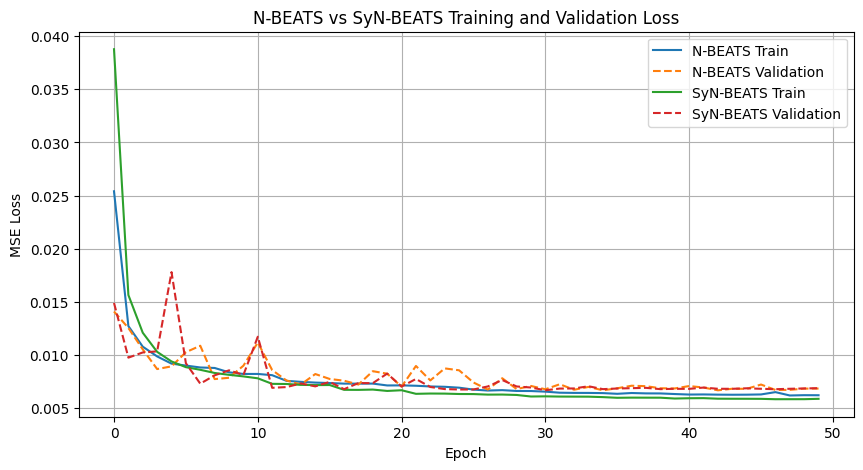

In [19]:
plt.figure(figsize=(10, 5))

for model_name, result in experiment_results.items():
    plt.plot(result["train_losses"], label=f"{model_name} Train")
    plt.plot(result["val_losses"], linestyle="--", label=f"{model_name} Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("N-BEATS vs SyN-BEATS Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

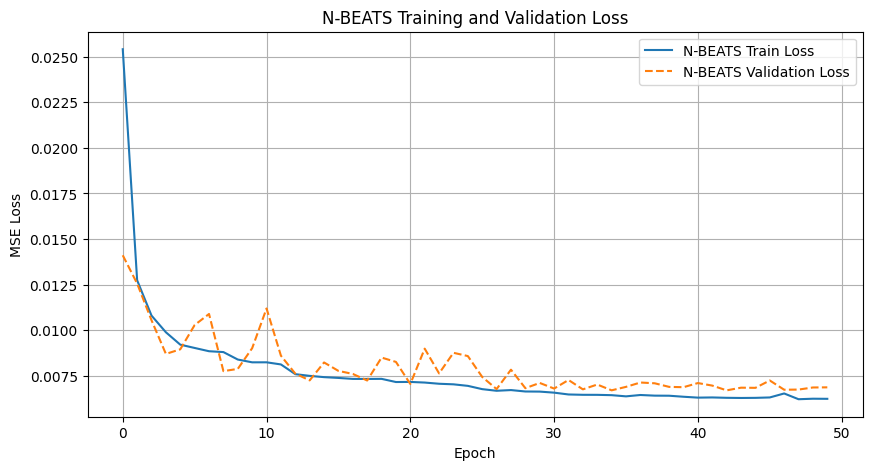

In [20]:
plt.figure(figsize=(10, 5))

result = experiment_results["N-BEATS"]

plt.plot(result["train_losses"], label="N-BEATS Train Loss")
plt.plot(result["val_losses"], linestyle="--", label="N-BEATS Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("N-BEATS Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

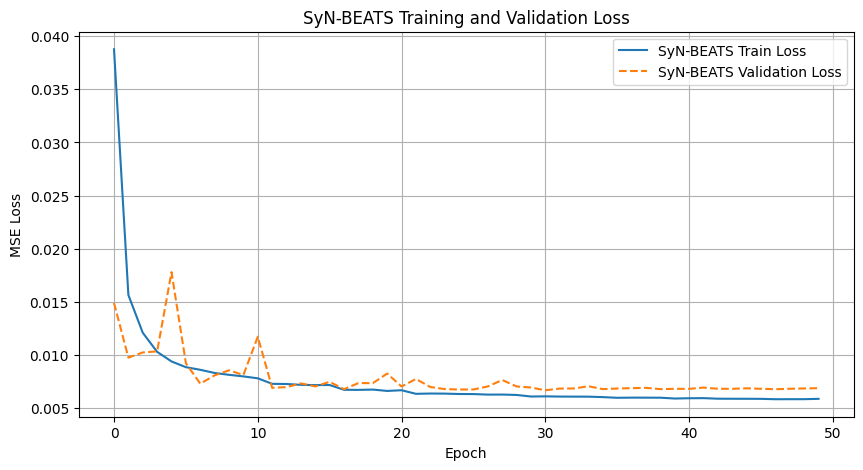

In [21]:
plt.figure(figsize=(10, 5))

result = experiment_results["SyN-BEATS"]

plt.plot(result["train_losses"], label="SyN-BEATS Train Loss")
plt.plot(result["val_losses"], linestyle="--", label="SyN-BEATS Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("SyN-BEATS Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
def predict_model(model):
    model.eval()

    test_predictions = []
    test_actuals = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)

            y_pred = model(X_batch)

            test_predictions.append(y_pred.cpu().numpy())
            test_actuals.append(y_batch.numpy())

    test_predictions = np.vstack(test_predictions)
    test_actuals = np.vstack(test_actuals)

    return test_predictions, test_actuals

def calculate_metrics(actuals, predictions):
    mae = mean_absolute_error(actuals, predictions)
    mse = mean_squared_error(actuals, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(actuals, predictions)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [23]:
metrics_scaled = {}

for model_name, result in experiment_results.items():
    test_predictions_scaled, test_actuals_scaled = predict_model(result["model"])

    result["test_predictions_scaled"] = test_predictions_scaled
    result["test_actuals_scaled"] = test_actuals_scaled

    metrics_scaled[model_name] = calculate_metrics(
        test_actuals_scaled,
        test_predictions_scaled
    )

metrics_scaled_df = pd.DataFrame(metrics_scaled).T

print("Metrics WITHOUT inverse scaling")
display(metrics_scaled_df)

Metrics WITHOUT inverse scaling


,MAE,MSE,RMSE,R2
N-BEATS,0.029100,0.003235,0.056873,0.965719
SyN-BEATS,0.027798,0.003107,0.055741,0.967068


In [24]:
improvement_scaled = metrics_scaled_df.loc["N-BEATS"] - metrics_scaled_df.loc["SyN-BEATS"]

# For R2, higher is better, so improvement is SyN-BEATS - N-BEATS
improvement_scaled["R2"] = (
    metrics_scaled_df.loc["SyN-BEATS", "R2"]
    - metrics_scaled_df.loc["N-BEATS", "R2"]
)

improvement_scaled.name = "SyN-BEATS improvement"

comparison_scaled_df = pd.concat([
    metrics_scaled_df,
    improvement_scaled.to_frame().T
])

display(comparison_scaled_df)

,MAE,MSE,RMSE,R2
N-BEATS,0.029100,0.003235,0.056873,0.965719
SyN-BEATS,0.027798,0.003107,0.055741,0.967068
SyN-BEATS improvement,0.001303,0.000127,0.001132,0.001349


In [25]:
def inverse_scale_2d(values, scaler):
    original_shape = values.shape
    values_reshaped = values.reshape(-1, 1)
    values_original = scaler.inverse_transform(values_reshaped)
    return values_original.reshape(original_shape)


def calculate_metrics(actuals, predictions):
    mae = mean_absolute_error(actuals, predictions)
    mse = mean_squared_error(actuals, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(actuals, predictions)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }


metrics = {}

for model_name, result in experiment_results.items():
    test_predictions_scaled, test_actuals_scaled = predict_model(result["model"])

    test_predictions_original = inverse_scale_2d(test_predictions_scaled, y_scaler)
    test_actuals_original = inverse_scale_2d(test_actuals_scaled, y_scaler)

    result["test_predictions_original"] = test_predictions_original
    result["test_actuals_original"] = test_actuals_original

    metrics[model_name] = calculate_metrics(
        test_actuals_original,
        test_predictions_original
    )

metrics_df = pd.DataFrame(metrics).T

print("Metrics WITH inverse scaling in original CO2 scale")
display(metrics_df)

Metrics WITH inverse scaling in original CO2 scale


,MAE,MSE,RMSE,R2
N-BEATS,10.631464,431.717468,20.777812,0.965719
SyN-BEATS,10.155556,414.704102,20.364285,0.967068


In [26]:
improvement = metrics_df.loc["N-BEATS"] - metrics_df.loc["SyN-BEATS"]

# For R2, higher is better, so improvement is SyN-BEATS - N-BEATS
improvement["R2"] = metrics_df.loc["SyN-BEATS", "R2"] - metrics_df.loc["N-BEATS", "R2"]

improvement.name = "SyN-BEATS improvement"

comparison_df = pd.concat([metrics_df, improvement.to_frame().T])

display(comparison_df)

,MAE,MSE,RMSE,R2
N-BEATS,10.631464,431.717468,20.777812,0.965719
SyN-BEATS,10.155556,414.704102,20.364285,0.967068
SyN-BEATS improvement,0.475908,17.013367,0.413527,0.001349


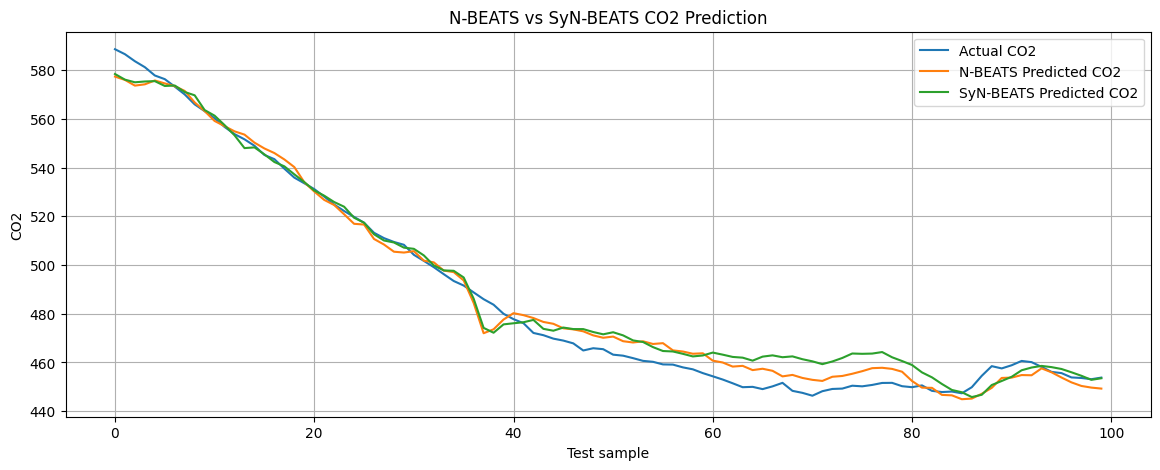

In [27]:
plt.figure(figsize=(14, 5))

plot_points = 100
forecast_step = 0

actuals = experiment_results["N-BEATS"]["test_actuals_original"]

plt.plot(
    actuals[:plot_points, forecast_step],
    label="Actual CO2"
)

for model_name, result in experiment_results.items():
    plt.plot(
        result["test_predictions_original"][:plot_points, forecast_step],
        label=f"{model_name} Predicted CO2"
    )

plt.xlabel("Test sample")
plt.ylabel("CO2")
plt.title("N-BEATS vs SyN-BEATS CO2 Prediction")
plt.legend()
plt.grid(True)
plt.show()

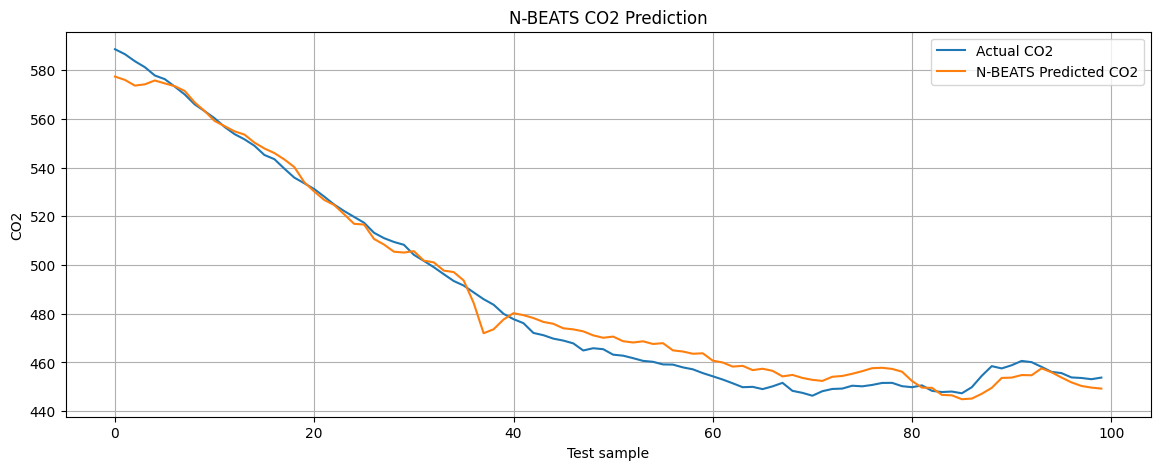

In [28]:
plt.figure(figsize=(14, 5))

plot_points = 100
forecast_step = 0

actuals = experiment_results["N-BEATS"]["test_actuals_original"]
predictions = experiment_results["N-BEATS"]["test_predictions_original"]

plt.plot(
    actuals[:plot_points, forecast_step],
    label="Actual CO2"
)

plt.plot(
    predictions[:plot_points, forecast_step],
    label="N-BEATS Predicted CO2"
)

plt.xlabel("Test sample")
plt.ylabel("CO2")
plt.title("N-BEATS CO2 Prediction")
plt.legend()
plt.grid(True)
plt.show()

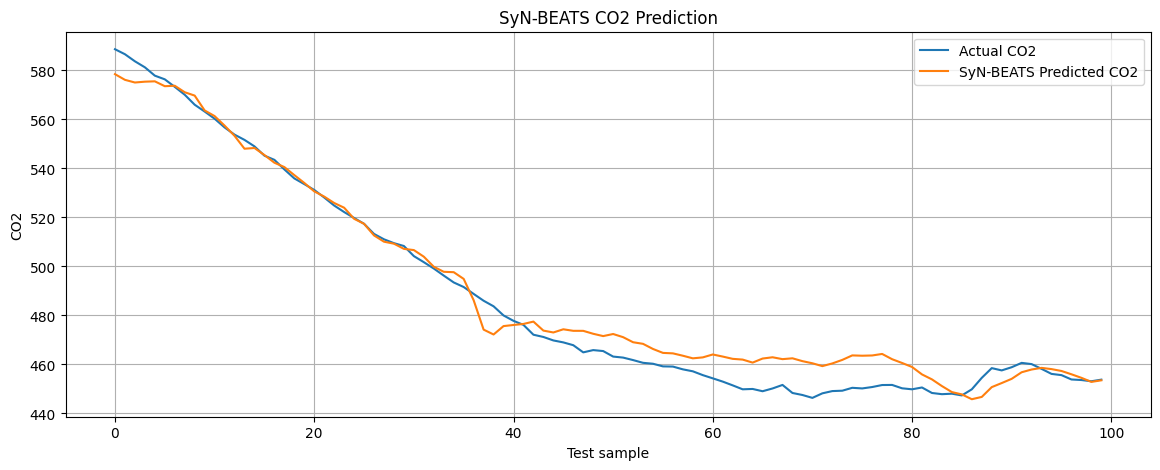

In [29]:
plt.figure(figsize=(14, 5))

plot_points = 100
forecast_step = 0

actuals = experiment_results["SyN-BEATS"]["test_actuals_original"]
predictions = experiment_results["SyN-BEATS"]["test_predictions_original"]

plt.plot(
    actuals[:plot_points, forecast_step],
    label="Actual CO2"
)

plt.plot(
    predictions[:plot_points, forecast_step],
    label="SyN-BEATS Predicted CO2"
)

plt.xlabel("Test sample")
plt.ylabel("CO2")
plt.title("SyN-BEATS CO2 Prediction")
plt.legend()
plt.grid(True)
plt.show()